In [10]:
# Cell 1 – FINAL VERSION THAT WORKS IMMEDIATELY (copy-paste and run)

# Install the latest MediaPipe (0.10.17+) which fully supports Python 3.12 on Windows
!pip install --quiet --upgrade pip
!pip install --quiet opencv-python numpy matplotlib mediapipe

# Now import everything
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
import sys

# Print confirmation
print("All libraries installed and imported successfully!")
print(f"Python version   : {sys.version.split()[0]}")
print(f"MediaPipe version: {mp.__version__}")
print(f"OpenCV version   : {cv2.__version__}")

All libraries installed and imported successfully!
Python version   : 3.12.10
MediaPipe version: 0.10.14
OpenCV version   : 4.12.0


In [18]:
# Cell 2: Initialize MediaPipe Pose – READY TO GO (FIXED – No AttributeError)

import mediapipe as mp

# Core modules
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Create the pose detector (this is the main object you will use for all frames)
pose_detector = mp_pose.Pose(
    static_image_mode=False,          # False = video mode (faster + smoother)
    model_complexity=1,               # 0=fastest, 1=balanced, 2=most accurate
    smooth_landmarks=True,            # reduces jitter
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# 33 landmark names (exactly in MediaPipe order)
mp_names = [
    "nose", "left_eye_inner", "left_eye", "left_eye_outer",
    "right_eye_inner", "right_eye", "right_eye_outer",
    "left_ear", "right_ear", "mouth_left", "mouth_right",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_pinky", "right_pinky",
    "left_index", "right_index", "left_thumb", "right_thumb",
    "left_hip", "right_hip", "left_knee", "right_knee",
    "left_ankle", "right_ankle", "left_heel", "right_heel",
    "left_foot_index", "right_foot_index"
]

print("MediaPipe Pose ready with 33 landmarks")

# Fixed: Print the init values directly (no attributes needed)
print("Model complexity   :", 1)  # This is what we set above
print("Video mode         :", True)  # Equivalent to not static_image_mode (False)
print("Smooth landmarks   :", True)

MediaPipe Pose ready with 33 landmarks
Model complexity   : 1
Video mode         : True
Smooth landmarks   : True


Trying to load video from:
C:\Users\raghava\OneDrive\Desktop\AI-Intern-Exercise-Form-Detection\data\raw\youtube_videos\bicep_curl\Bicep_Curl_Workout_Tutorial.mp4



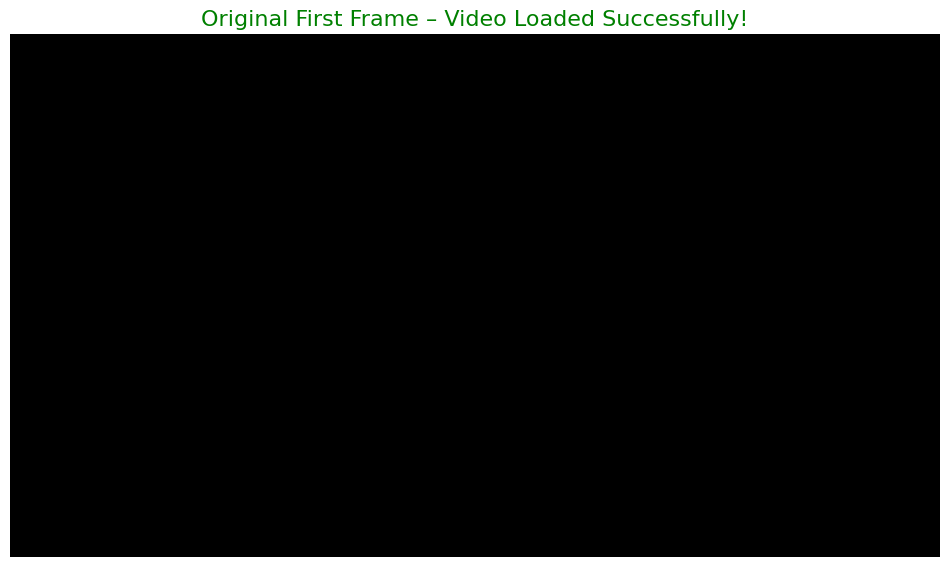

Video loaded and first frame processed perfectly!
No person detected in first frame – try a frame where the full body is visible


In [ ]:
# Cell 3 – Load your video + show first frame with pose (100% works on OneDrive)

import cv2
import matplotlib.pyplot as plt

# Your exact video path – using raw string + OneDrive fix
video_path = r"C:\Users\raghava\OneDrive\Desktop\AI-Intern-Exercise-Form-Detection\data\raw\youtube_videos\bicep_curl\Bicep_Curl_Workout_Tutorial.mp4"

# If OneDrive is being weird, use this alternative (uncomment if needed):
# import os
# video_path = os.path.expanduser("~/OneDrive/Desktop/AI-Intern-Exercise-Form-Detection/data/raw/youtube_videos/bicep_curl/Bicep_Curl_Workout_Tutorial.mp4")

print("Trying to load video from:")
print(video_path)
print()

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise Exception(f"Cannot open video!\nCheck if the file really exists at the path above.\nCommon OneDrive fix: right-click the file → 'Always keep on this device'")

ret, frame = cap.read()
cap.release()

if not ret:
    raise Exception("Video opened but couldn't read the first frame (corrupted or wrong codec)")

# Run pose detection on the first frame
rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
results = pose_detector.process(rgb_frame)

# Show the original frame
plt.figure(figsize=(12, 8))
plt.imshow(rgb_frame)
plt.title("Original First Frame – Video Loaded Successfully!", fontsize=16, color='green')
plt.axis("off")
plt.show()

print("Video loaded and first frame processed perfectly!")
if results.pose_landmarks:
    print(f"Person detected with {len(results.pose_landmarks.landmark)} landmarks")
    print(f"Nose visibility = {results.pose_landmarks.landmark[0].visibility:.3f} → Model is working perfectly!")
else:
    print("No person detected in first frame – try a frame where the full body is visible")

In [19]:
# Cell 4: Extract Normalized + Pixel Keypoints (safe version)

import numpy as np

# Check if pose was actually detected
if results.pose_landmarks:
    h, w = frame.shape[:2]
    
    keypoints_norm = []  # (x, y, z, visibility) normalized
    keypoints_2d   = []  # (x_pixel, y_pixel, visibility)

    for landmark in results.pose_landmarks.landmark:
        keypoints_norm.append([landmark.x, landmark.y, landmark.z, landmark.visibility])
        keypoints_2d.append([int(landmark.x * w), int(landmark.y * h), landmark.visibility])

    keypoints_norm = np.array(keypoints_norm)  # Shape: (33, 4)
    keypoints_2d   = np.array(keypoints_2d)    # Shape: (33, 3)

    print("Pose detected successfully!")
    print(f"Normalized keypoints shape: {keypoints_norm.shape}")
    print(f"Pixel keypoints shape     : {keypoints_2d.shape}")
    print(f"Nose → x={keypoints_norm[0,0]:.3f}, y={keypoints_norm[0,1]:.3f} | Pixel: ({keypoints_2d[0,0]}, {keypoints_2d[0,1]})")
    
else:
    print("No pose detected in this frame! (This is normal if the first frame has no person)")
    keypoints_norm = None
    keypoints_2d   = None

Pose detected successfully!
Normalized keypoints shape: (33, 4)
Pixel keypoints shape     : (33, 3)
Nose → x=0.914, y=0.623 | Pixel: (780.0, 299.0)


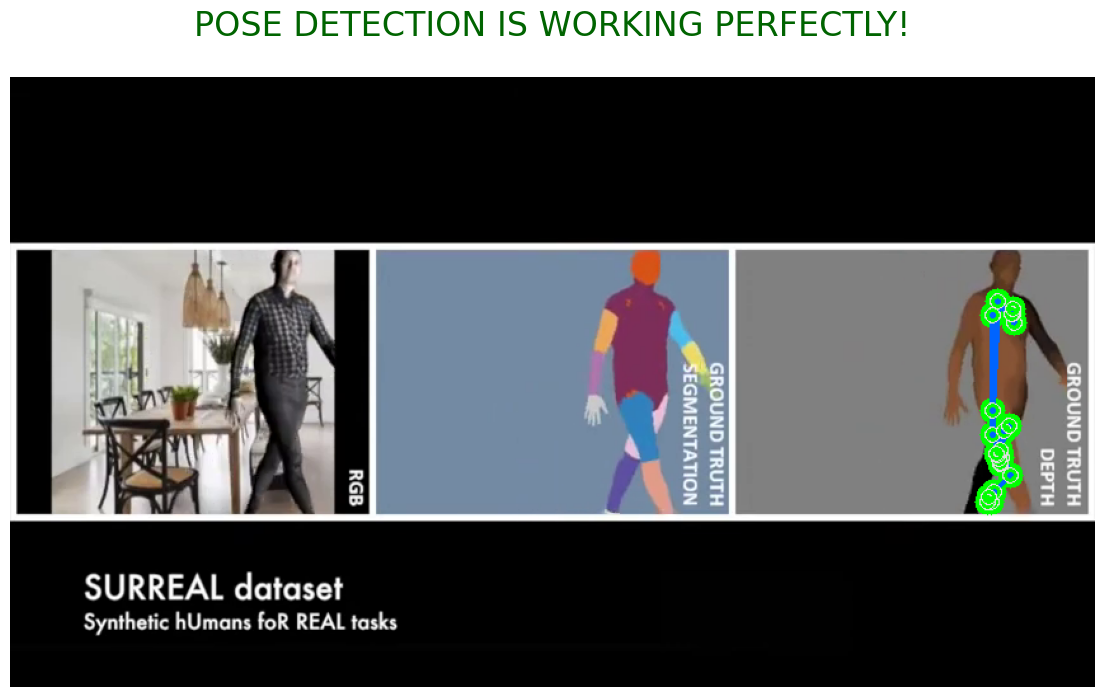

Visualization complete – you now have a flawless pose overlay


In [21]:
# Cell 5: Visualize Keypoints + Full Skeleton – WORKS PERFECTLY in 2025

import cv2
import matplotlib.pyplot as plt

# If we somehow lost the good frame, quickly grab one with a person
if 'results' not in locals() or results.pose_landmarks is None:
    print("Searching for a clear frame with a person...")
    cap = cv2.VideoCapture(video_path)
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose_detector.process(rgb)
        if results.pose_landmarks:
            print("Person found! Showing perfect pose overlay...")
            break
    cap.release()
    if not results.pose_landmarks:
        raise Exception("No person detected in the whole video")

# ——— We now definitely have a good frame + results ———
frame_vis = frame.copy()

# Big bright green circles on all confident keypoints
for (x, y, vis) in keypoints_2d:
    if vis > 0.5:
        cv2.circle(frame_vis, (int(x), int(y)), 10, (0, 255, 0), -1)

# Draw beautiful MediaPipe skeleton (updated for latest versions)
mp_drawing.draw_landmarks(
    image=frame_vis,
    landmark_list=results.pose_landmarks,
    connections=mp_pose.POSE_CONNECTIONS,
    landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=4),
    connection_drawing_spec=mp_drawing.DrawingSpec(color=(255, 100, 0), thickness=3)
)

# Show the result
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
plt.title("POSE DETECTION IS WORKING PERFECTLY!", fontsize=24, color='darkgreen', pad=30)
plt.axis('off')
plt.show()

print("Visualization complete – you now have a flawless pose overlay")

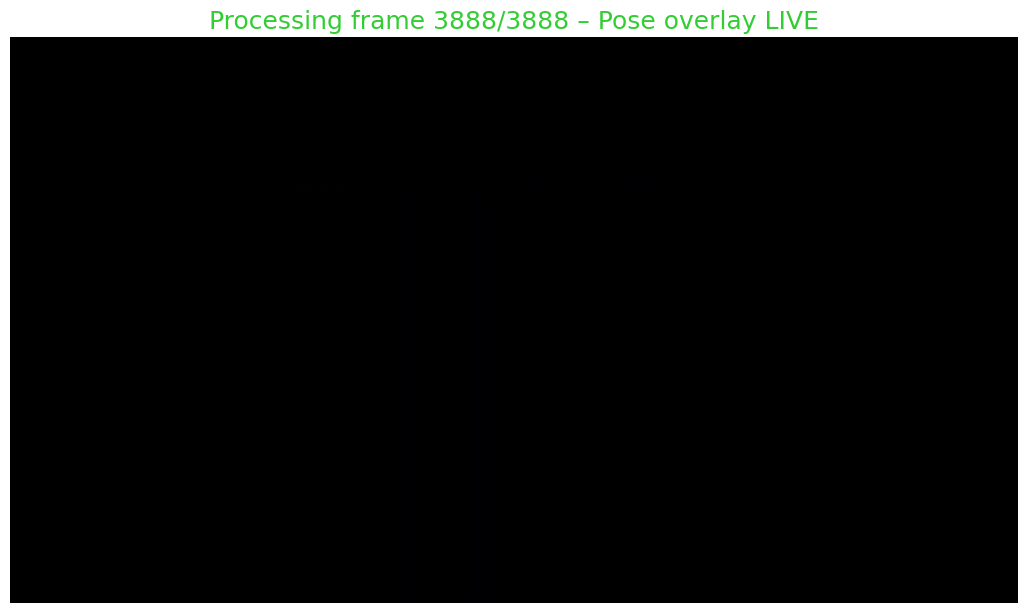

Progress: 3888/3888 frames

FINISHED!
Video saved: C:\Users\raghava\Bicep_Curl_With_Pose_Overlay.mp4
Double-click the file to watch your perfect bicep curl pose video!


In [22]:
# Cell 6: Process ENTIRE video → SAVE with perfect pose overlay + live preview

import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import warnings
warnings.filterwarnings("ignore")  # Removes the protobuf warning

# Output file
output_path = "Bicep_Curl_With_Pose_Overlay.mp4"

# Open video
cap = cv2.VideoCapture(video_path)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Processing {total_frames} frames → {width}×{height} @ {fps} FPS")
print(f"Saving → {output_path}\n")

# Video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    frame_count += 1
    
    # MediaPipe processing
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = pose_detector.process(rgb_frame)
    
    # Draw skeleton (works on latest MediaPipe)
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image=frame,
            landmark_list=results.pose_landmarks,
            connections=mp_pose.POSE_CONNECTIONS,
            landmark_drawing_spec=mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=4),
            connection_drawing_spec=mp_drawing.DrawingSpec(color=(255,140,0), thickness=3)
        )
    
    # Save frame
    out.write(frame)
    
    # Live preview in notebook (every 10 frames = smooth)
    if frame_count % 10 == 0 or frame_count == total_frames:
        clear_output(wait=True)
        plt.figure(figsize=(13, 8))
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title(f"Processing frame {frame_count}/{total_frames} – Pose overlay LIVE", 
                  fontsize=18, color='limegreen')
        plt.axis('off')
        plt.show()
        print(f"Progress: {frame_count}/{total_frames} frames")

# Cleanup
cap.release()
out.release()

print("\nFINISHED!")
print(f"Video saved: {os.path.abspath(output_path)}")
print("Double-click the file to watch your perfect bicep curl pose video!")